In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import random
from ucimlrepo import fetch_ucirepo
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
from sklearn.metrics import confusion_matrix, classification_report

In [2]:
# set random seeds for reproducibility
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

In [3]:
# fetch dataset 
multivariate_gait_data = fetch_ucirepo(id=760)
df = multivariate_gait_data.data.features

### LSTM

In [4]:
# randomly select training/testing subjects (80/20 split)
# split data by subjects to avoid data leakage
train_subjects = random.sample(range(1, 11), 8)
test_subjects = [i for i in range(1, 11) if i not in train_subjects]

train = df[df["subject"].isin(train_subjects)]
test = df[df["subject"].isin(test_subjects)]

In [5]:
def construct_sequences(df):
    """ 
    Construct sequences of leg/joint angles over time 
    Each sequence has shape 101 x 6 (101 points in time x 6 angles)
    """
    grouped = df.groupby(["subject", "condition", "replication"])

    labels = []
    sequences = []

    for id, group in grouped:
        # condition at index 1 in the groupby
        labels.append(id[1])
        # get measurements for each leg and joint combination over time
        pivot = group.pivot_table(
            index="time", 
            columns=["leg", "joint"], 
            values="angle"
        )
        sequences.append(pivot.values)

    sequences = np.array(sequences)
    labels = np.array(labels)

    return sequences, labels

In [6]:
# format the data for training and testing
X_train, y_train = construct_sequences(train)
X_test, y_test = construct_sequences(test)

# flatten the data to apply standardization
n_instances, n_timepts, n_features = X_train.shape
X_train_flat = X_train.reshape(-1, n_features)
X_test_flat = X_test.reshape(-1, n_features)

# scale the data and reshape it into a 3D tensor
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train_flat).reshape(n_instances, n_timepts, n_features)
X_test = scaler.transform(X_test_flat).reshape(-1, n_timepts, n_features)

# 0-indexed labels
y_train = y_train - 1
y_test = y_test - 1

In [7]:
# convert to PyTorch tensors and create data loaders
X_tr = torch.tensor(X_train, dtype=torch.float32)
y_tr = torch.tensor(y_train, dtype=torch.long)
X_te = torch.tensor(X_test, dtype=torch.float32)
y_te = torch.tensor(y_test, dtype=torch.long)

train_loader = DataLoader(TensorDataset(X_tr, y_tr), batch_size=32, shuffle=True)

### Experimenting with the number of LSTM layers

In [8]:
# define a single layer model as a baseline
n_classes = len(np.unique(y_train))

class GaitLSTM_1Layer(nn.Module):
    def __init__(self, n_features, n_classes):
        super().__init__()
        # single LSTM layer: expands 6 leg/joint combinations into 64 hidden units
        # to learn movement patterns across the 101 frames of each trial
        self.lstm1 = nn.LSTM(n_features, 64, batch_first=True)

        # randomly zero out 30% of hidden units to avoid memorizing training subjects
        self.drop1 = nn.Dropout(0.3)

        # maps the 64-unit summary directly to one score per walking condition
        # (no 2nd LSTM to compress, so input size is 64 instead of 32)
        self.fc    = nn.Linear(64, n_classes)

    def forward(self, x):
        """
        Pass a batch of trials through the model and return a predicted walking condition for each.
        (a single trial = one subject + one condition + one replication, each trial produces one sequence of 101 frames)
        """
        # x is (batch, 101 frames, 6 leg/joint combinations)
        # run full trial through the LSTM
        x, _ = self.lstm1(x)

        # discard all frames except the last, which summarizes the full trial
        x = self.drop1(x[:, -1, :])

        # output one score per walking condition
        return self.fc(x)

model_1layer     = GaitLSTM_1Layer(n_features, n_classes)
optimizer_1layer = torch.optim.Adam(model_1layer.parameters())
criterion        = nn.CrossEntropyLoss()

print(model_1layer)

GaitLSTM_1Layer(
  (lstm1): LSTM(6, 64, batch_first=True)
  (drop1): Dropout(p=0.3, inplace=False)
  (fc): Linear(in_features=64, out_features=3, bias=True)
)


In [9]:
# train the 1-layer model
train_losses_1layer = []

for epoch in range(50):
    model_1layer.train()  # set model to training mode (enables dropout)
    epoch_loss = 0
    for xb, yb in train_loader:
        # clear gradients from previous batch
        optimizer_1layer.zero_grad()

        # compute loss between predictions and true labels
        loss = criterion(model_1layer(xb), yb)

        # backpropagate the loss
        loss.backward()

        # update model weights
        optimizer_1layer.step()

        # accumulate batch loss
        epoch_loss += loss.item()

    # average loss across all batches in the epoch
    avg_loss = epoch_loss / len(train_loader)

    # store values for plotting
    train_losses_1layer.append(avg_loss)
    if (epoch + 1) % 10 == 0:
        # print progress every 10 epochs
        print(f"Epoch {epoch+1}/50  loss: {avg_loss:.4f}")

Epoch 10/50  loss: 0.3108
Epoch 20/50  loss: 0.1521
Epoch 30/50  loss: 0.0327
Epoch 40/50  loss: 0.0071
Epoch 50/50  loss: 0.0034


In [10]:
# evaluate 1-layer model on test set
model_1layer.eval()

# disable gradient tracking since we're not training
with torch.no_grad():
    # run test trials through model, output one score per condition
    logits_1layer = model_1layer(X_te)

    # take the highest score as the predicted condition
    y_pred_1layer = logits_1layer.argmax(dim=1).numpy()

# proportion of correct predictions
acc_1layer = (y_pred_1layer == y_te.numpy()).mean()
print(f"1-layer test accuracy: {acc_1layer:.3f}")

1-layer test accuracy: 0.833


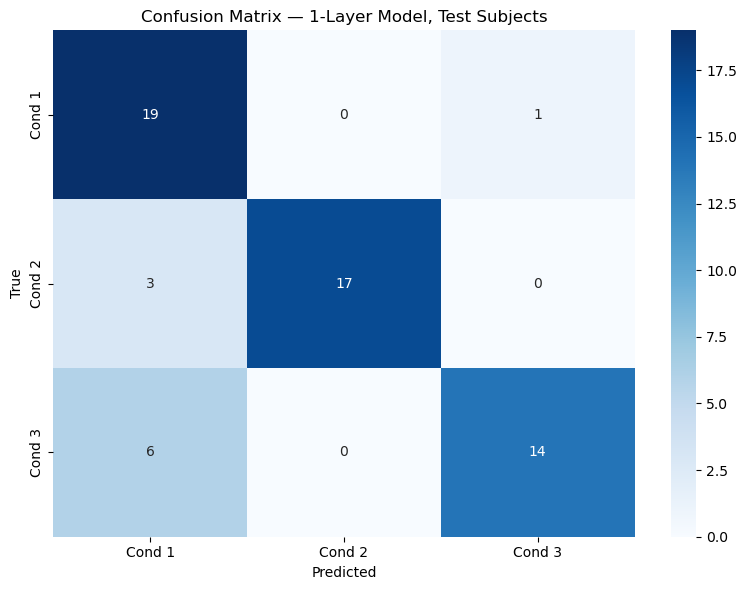

              precision    recall  f1-score   support

      Cond 1       0.68      0.95      0.79        20
      Cond 2       1.00      0.85      0.92        20
      Cond 3       0.93      0.70      0.80        20

    accuracy                           0.83        60
   macro avg       0.87      0.83      0.84        60
weighted avg       0.87      0.83      0.84        60



In [11]:
# confusion matrix for 1-layer model
cm_1layer = confusion_matrix(y_te.numpy(), y_pred_1layer)
plt.figure(figsize=(8, 6))
sns.heatmap(
    cm_1layer, annot=True, fmt="d", cmap="Blues",
    xticklabels=[f"Cond {i+1}" for i in range(n_classes)],  # predicted conditions
    yticklabels=[f"Cond {i+1}" for i in range(n_classes)]   # true conditions
)
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix — 1-Layer Model, Test Subjects")
plt.tight_layout()
plt.show()

# per-condition breakdown of precision, recall, and f1-score
print(classification_report(
    y_te.numpy(), y_pred_1layer,
    target_names=[f"Cond {i+1}" for i in range(n_classes)]
))

#### Adding a 2nd LSTM layer

In [12]:
# define the 2-layer model to see if an extra layer improves performance
n_classes = len(np.unique(y_train))

class GaitLSTM(nn.Module):
    def __init__(self, n_features, n_classes):
        super().__init__()
        # 1st LSTM layer: expands 6 leg/joint combinations into 64 hidden units
        # to learn movement patterns across the 101 frames of each trial
        self.lstm1 = nn.LSTM(n_features, 64, batch_first=True)

        # randomly zero out 30% of hidden units to avoid memorizing training subjects
        self.drop1 = nn.Dropout(0.3)

        # 2nd LSTM layer: compresses 64 to 32, keeping only the most relevant patterns
        self.lstm2 = nn.LSTM(64, 32, batch_first=True)
        
        # dropout again before making final prediction
        self.drop2 = nn.Dropout(0.3)

        # maps 32 unit summary to one score per walking condition
        self.fc    = nn.Linear(32, n_classes)

    def forward(self, x):
        """
        Pass a batch of trials through the model and return a predicted walking condition for each.
        (a single trial = one subject + one condition + one replication, each trial produces one sequence of 101 frames)
        """
        # x is (batch, 101 time frames, 6 leg/joint combinations)
        # run full trial through the first LSTM
        x, _ = self.lstm1(x)
        x = self.drop1(x)

        # run through 2nd LSTM
        x, _ = self.lstm2(x)

        # discard all frames except the last, which summarizes the full trial
        x = self.drop2(x[:, -1, :])
        
        # output one score per walking condition
        return self.fc(x)

model     = GaitLSTM(n_features, n_classes)
optimizer = torch.optim.Adam(model.parameters())
criterion = nn.CrossEntropyLoss()

print(model)

GaitLSTM(
  (lstm1): LSTM(6, 64, batch_first=True)
  (drop1): Dropout(p=0.3, inplace=False)
  (lstm2): LSTM(64, 32, batch_first=True)
  (drop2): Dropout(p=0.3, inplace=False)
  (fc): Linear(in_features=32, out_features=3, bias=True)
)


In [13]:
# train the 2-layer model
train_losses = []

for epoch in range(50):
    model.train()  # set model to training mode (enables dropout)
    epoch_loss = 0
    for xb, yb in train_loader:
        # clear gradients from previous batch
        optimizer.zero_grad()

        # compute loss between predictions and true labels
        loss = criterion(model(xb), yb)
        
        # backpropagate the loss
        loss.backward()
       
       # update model weights
        optimizer.step()

        # accumulate batch loss
        epoch_loss += loss.item()
    
    # average loss across all batches in the epoch
    avg_loss = epoch_loss / len(train_loader)
    
    # store values for plotting
    train_losses.append(avg_loss)
    if (epoch + 1) % 10 == 0:
        # print progress every 10 epochs
        print(f"Epoch {epoch+1}/50  loss: {avg_loss:.4f}")

Epoch 10/50  loss: 0.3079
Epoch 20/50  loss: 0.1113
Epoch 30/50  loss: 0.0283
Epoch 40/50  loss: 0.0087
Epoch 50/50  loss: 0.0053


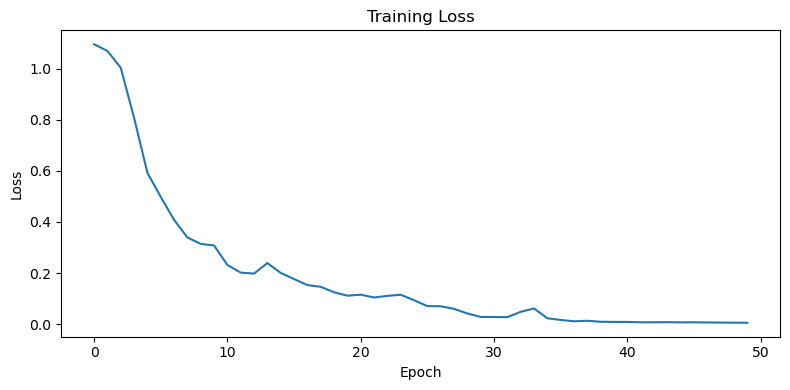

In [14]:
# plot training loss
plt.figure(figsize=(8, 4))
plt.plot(train_losses)
plt.title("Training Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.tight_layout()
plt.show()

The training loss dropped steeply in the first few epochs, meaning the model quickly learned to distinguish between walking conditions. It then continued to decrease gradually.

In [15]:
# evaluate 2-layer model on test set
model.eval()

# disable gradient tracking since we're not training
with torch.no_grad():
    # run test trials through model, output one score per condition
    logits = model(X_te)

    # take the highest score as the predicted condition
    y_pred = logits.argmax(dim=1).numpy()

# proportion of correct predictions
test_acc = (y_pred == y_te.numpy()).mean()
print(f"Test accuracy: {test_acc:.3f}")

Test accuracy: 0.800


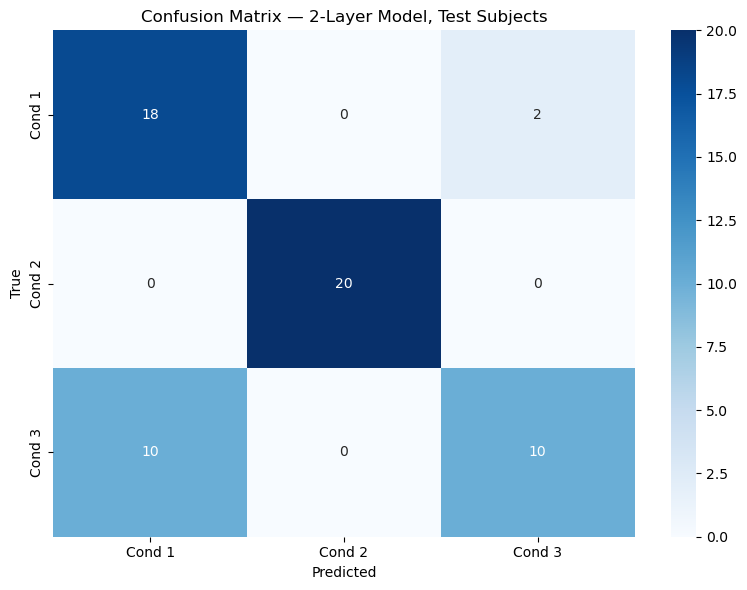

              precision    recall  f1-score   support

      Cond 1       0.64      0.90      0.75        20
      Cond 2       1.00      1.00      1.00        20
      Cond 3       0.83      0.50      0.62        20

    accuracy                           0.80        60
   macro avg       0.83      0.80      0.79        60
weighted avg       0.83      0.80      0.79        60



In [16]:
# confusion matrix - show which conditions the model confused with each other
cm = confusion_matrix(y_te.numpy(), y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(
    cm, annot=True, fmt="d", cmap="Blues",
    xticklabels=[f"Cond {i+1}" for i in range(n_classes)], # predicted conditions
    yticklabels=[f"Cond {i+1}" for i in range(n_classes)] # true conditions
)
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix — 2-Layer Model, Test Subjects")
plt.tight_layout()
plt.show()

print(classification_report(
    y_te.numpy(), y_pred,
    target_names=[f"Cond {i+1}" for i in range(n_classes)]
))

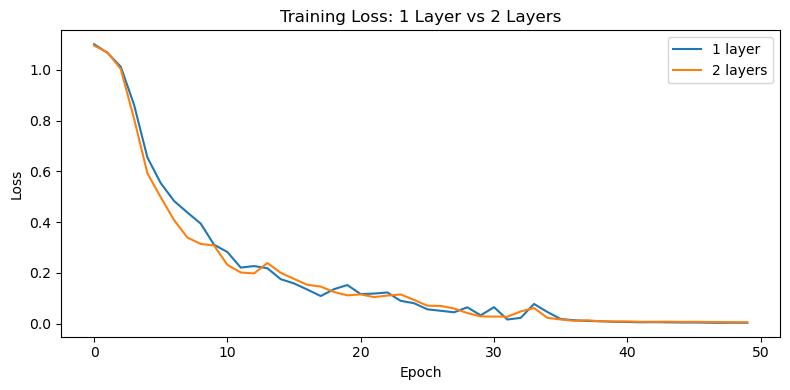

1-layer test accuracy: 0.833
2-layer test accuracy: 0.800


In [17]:
# compare training loss curves between 1-layer and 2-layer models
plt.figure(figsize=(8, 4))
plt.plot(train_losses_1layer, label='1 layer')
plt.plot(train_losses, label='2 layers')
plt.title('Training Loss: 1 Layer vs 2 Layers')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.tight_layout()
plt.show()

# compare test accuracy
acc_2layer = (y_pred == y_te.numpy()).mean()
print(f'1-layer test accuracy: {acc_1layer:.3f}')
print(f'2-layer test accuracy: {acc_2layer:.3f}')

With a fixed random seed, the 1-layer model achieved 83% test accuracy compared to 80% for the 2-layer model. Both models struggled to distinguish between Conditions 1 and 3, suggesting the patterns between these two conditions are genuinely similar and difficult to separate with only 8 training subjects. The simpler 1-layer model generalized slightly better, indicating the dataset may be too small to benefit from the added complexity of a second LSTM layer.

### kNN with DTM (Data Time Warping)

In [18]:
from tslearn.neighbors import KNeighborsTimeSeriesClassifier

In [19]:
# number of training and test sequences
n_train = X_train.shape[0]
n_test  = X_test.shape[0]

print(f"Fitting KNN with DTW for {n_train} training sequences...")

# initialize KNN classifier for time series data
# DTW is used as the distance metric to compare sequences
# no need to precompute distance matrices since tslearn handles this internally
knn = KNeighborsTimeSeriesClassifier(n_neighbors=5, metric="dtw")


Fitting KNN with DTW for 240 training sequences...


With 80/20 split, 8 subjects are used for training.
Therefore with 8 subjects x 3 conditions x 10 replications = 240 training sequences

In [20]:
# fit model by storing training sequences and labels
# distances will be computed during prediction using DTW alignment
knn.fit(X_train, y_train)

,n_neighbors,5
,weights,'uniform'
,metric,'dtw'
,metric_params,None
,n_jobs,None
,verbose,0


In [21]:
# fit model by storing training sequences and labels
# distances will be computed during prediction using DTW alignment
knn.fit(X_train, y_train)

,n_neighbors,5
,weights,'uniform'
,metric,'dtw'
,metric_params,None
,n_jobs,None
,verbose,0


In [22]:
print(f"Predicting on {n_test} test sequences using DTW...")

# predict labels for test sequences
# for each test sample, DTW distances are computed to training samples
# and the majority label among nearest neighbors is returned
y_pred_knn = knn.predict(X_test)

Predicting on 60 test sequences using DTW...


With 80/20 split, 2 subjects are used for testing.
Therefore with 2 subjects x 3 conditions x 10 replications = 60 testing sequences

In [25]:
# evaluate KNN performance on test set
acc_knn = (y_pred_knn == y_test).mean()
print(f"KNN (DTW) test accuracy: {acc_knn:.3f}")

KNN (DTW) test accuracy: 1.000


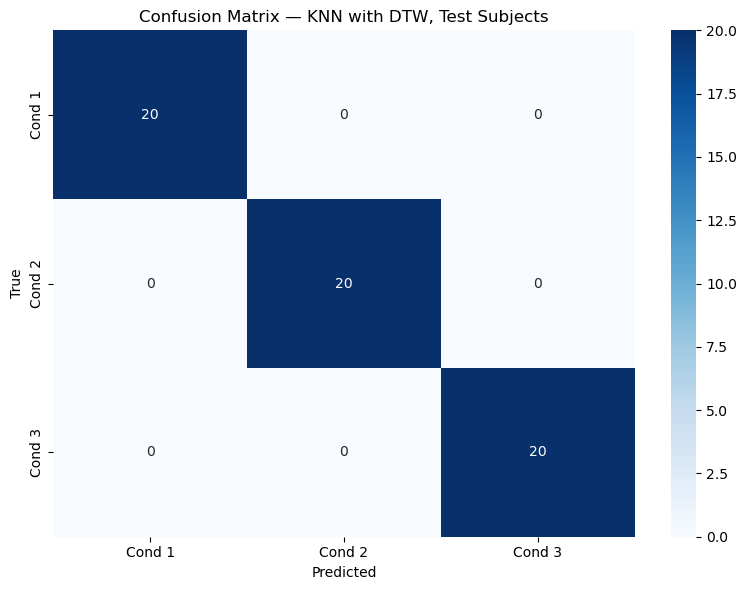

              precision    recall  f1-score   support

      Cond 1       1.00      1.00      1.00        20
      Cond 2       1.00      1.00      1.00        20
      Cond 3       1.00      1.00      1.00        20

    accuracy                           1.00        60
   macro avg       1.00      1.00      1.00        60
weighted avg       1.00      1.00      1.00        60



In [26]:
# confusion matrix — shows which conditions the model confused with each other
cm_knn = confusion_matrix(y_test, y_pred_knn)
plt.figure(figsize=(8, 6))
sns.heatmap(
    cm_knn, annot=True, fmt="d", cmap="Blues",
    xticklabels=[f"Cond {i+1}" for i in range(n_classes)],  # predicted conditions
    yticklabels=[f"Cond {i+1}" for i in range(n_classes)]   # true conditions
)
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix — KNN with DTW, Test Subjects")
plt.tight_layout()
plt.show()

# per-condition breakdown of precision, recall, and f1-score
print(classification_report(
    y_test, y_pred_knn,
    target_names=[f"Cond {i+1}" for i in range(n_classes)]
))

In [27]:
# compare test accuracy across all three models
acc_1layer = (y_pred_1layer == y_te.numpy()).mean()
acc_2layer = (y_pred == y_te.numpy()).mean()

print(f"1-layer LSTM accuracy:  {acc_1layer:.3f}")
print(f"2-layer LSTM accuracy:  {acc_2layer:.3f}")
print(f"KNN (DTW) accuracy:     {acc_knn:.3f}")

1-layer LSTM accuracy:  0.833
2-layer LSTM accuracy:  0.800
KNN (DTW) accuracy:     1.000


To validate whether the KNN–DTW model’s perfect classification performance is true or false, we compared the average Dynamic Time Warping (DTW) distances within the same class versus between different classes.

In [32]:
# compare within-class vs cross-class DTW distances
from tslearn.metrics import dtw

intra, inter = [], []

for i in range(len(X_train)):
    for j in range(i+1, len(X_train)):
        d = dtw(X_train[i], X_train[j])
        if y_train[i] == y_train[j]:
            intra.append(d)
        else:
            inter.append(d)

print("mean intra-class DTW:", np.mean(intra))
print("mean inter-class DTW:", np.mean(inter))

mean intra-class DTW: 10.089629891523897
mean inter-class DTW: 19.659634557599865


**1. Lower intra-class distance:**

The lower average DTW distance within the same class indicates that sequences belonging to the same condition exhibit strong temporal similarity. In other words, signals within each class follow consistent motion patterns that can be well-aligned using DTW.

**2. Higher inter-class distance:**

The significantly higher inter-class DTW distance shows that sequences from different classes are substantially more dissimilar in their temporal structure. Even after optimal time warping, the shapes of these sequences remain distinct.

**Explanation for 1.00 Accuracy:**

The fact that the intra-class DTW is lower than the inter-class DTW implies strong class separability in the time-series space. This creates an ideal scenario for a DTW-based KNN classifier, since:
- nearest neighbors are almost always from the correct class
- class boundaries are well-separated in temporal shape space
- warping does not blur class distinctions

As a result, the model achieving perfect accuracy (1.00) is consistent with the underlying data structure rather than indicating data leakage or model error. These distance patterns confirm that the dataset has strong intrinsic temporal class structure. This makes DTW-based nearest-neighbor classification highly effective. It also explains the observed perfect test performance.

**Limitations:**

Despite achieving perfect classification accuracy, the results should be interpreted in the context of the dataset’s structure. The large gap between intra-class and inter-class DTW distances indicates strong inherent separability in the time-series space, which makes the classification task relatively straightforward for a DTW-based KNN model. However, this also suggests that the evaluation may not be very challenging under the current setup, and the model’s performance may not generalize well to more realistic conditions involving higher noise, inter-subject variability, or less clearly separable motion patterns.